# 09. 発展トピック — スペクトル法・ソリトン・パターン・2D 波動

| 層 | セクション |
|---|---|
| Applied | 1. スペクトル法 〜 4. 2D 波動 |
| Advanced | 5. Advanced Notes |

有限差分の先にある 4 つの発展テーマを、`pde_book.advanced` の小さな実装で体験します:
**スペクトル法**(超高精度)、**KdV ソリトン**(非線形 + 分散)、**反応拡散パターン**(Turing)、**2 次元波動**。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import advanced, plotting
import numpy as np

## 1. スペクトル法 — FFT で微分する

周期境界では、微分は **Fourier 空間で波数 $ik$ を掛けるだけ**。これは差分近似ではなく **厳密** なので、
滑らかな関数に対して有限差分より桁違いに正確です。熱方程式では各モードが $e^{-\alpha k^2 t}$ で減衰し、
スペクトル法はこれを丸め誤差レベルで再現します(有限差分には離散化誤差が残る)。

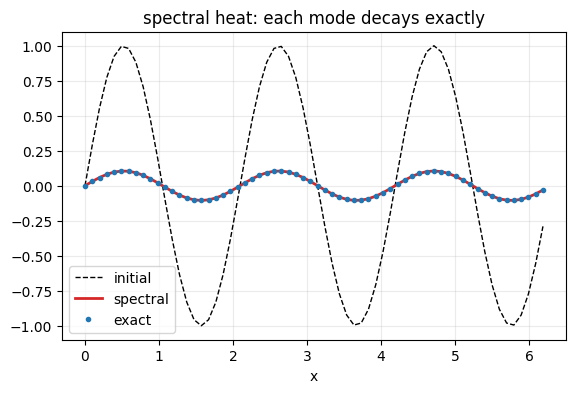

max |spectral - exact| = 4.718447854656915e-16 (machine precision)


In [3]:
# Spectral heat: machine-precision accurate on a periodic mode, vs FDM's O(dx^2) error.
n, length, alpha = 64, 2 * np.pi, 0.5
x = np.linspace(0, length, n, endpoint=False)
u0 = np.sin(3 * x)
dt, steps = 0.01, 50
U = advanced.solve_heat_spectral(u0, alpha, length, dt, steps)
exact = np.exp(-alpha * 9 * steps * dt) * np.sin(3 * x)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(x, u0, "k--", lw=1, label="initial")
ax.plot(x, U[-1], color="#d62728", lw=2, label="spectral")
ax.plot(x, exact, "o", ms=3, color="#1f77b4", label="exact")
ax.legend(); ax.grid(alpha=0.25); ax.set_xlabel("x")
ax.set_title("spectral heat: each mode decays exactly")
plt.show()
print("max |spectral - exact| =", float(np.max(np.abs(U[-1] - exact))), "(machine precision)")

## 2. KdV 方程式 — 非線形 + 分散がソリトンを作る

$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + \frac{\partial^3 u}{\partial x^3} = 0
$$

KdV は **非線形の急峻化**(Burgers と同じ)と **3 階微分の分散** が釣り合い、形を保って進む孤立波
**ソリトン** を生みます。背が高いほど速い。2 つのソリトンは衝突しても **すり抜けて形を保つ**(粒子のよう)——
これがソリトンの驚くべき性質です。

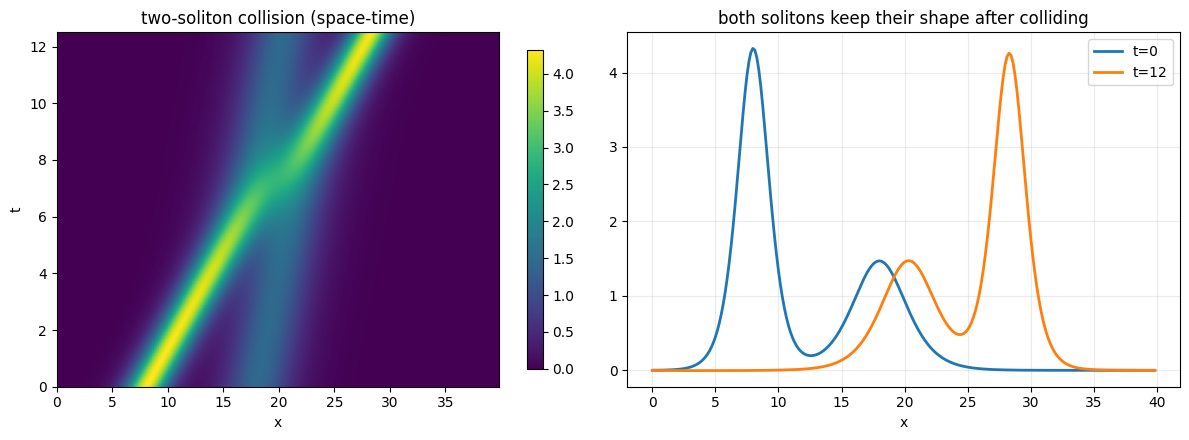

mass conserved: True | momentum drift: 0.0


In [4]:
# Two KdV solitons: the taller (faster) one catches up, passes through, and both survive.
n, length = 256, 40.0
dx = length / n
x = np.linspace(0, length, n, endpoint=False)
u0 = advanced.kdv_soliton(x, 0, 1.2, 8.0, length) + advanced.kdv_soliton(x, 0, 0.7, 18.0, length)
dt, steps = 0.0025, 5000
U = advanced.solve_kdv(u0, dx, dt, steps)
t = np.arange(steps + 1) * dt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
plotting.space_time_heatmap(U[::20], x, t[::20], ax=a1, cmap="viridis",
                            title="two-soliton collision (space-time)")
for k, lab in [(0, "t=0"), (steps, f"t={steps * dt:.0f}")]:
    a2.plot(x, U[k], lw=2, label=lab)
a2.legend(); a2.grid(alpha=0.25); a2.set_xlabel("x")
a2.set_title("both solitons keep their shape after colliding")
fig.tight_layout()
plt.show()
print("mass conserved:", abs(U[-1].sum() - U[0].sum()) * dx < 1e-6,
      "| momentum drift:", round(float(abs((U[-1]**2).sum() - (U[0]**2).sum()) * dx), 6))

## 3. 反応拡散 — Turing パターン (Gray-Scott)

2 つの化学種が **拡散しながら反応** すると、一様な状態が自発的に崩れて斑点や縞ができます
(**Turing 不安定性**、動物の模様の起源とされる)。Gray-Scott モデル

$$
u_t = D_u\nabla^2 u - uv^2 + F(1-u),\qquad v_t = D_v\nabla^2 v + uv^2 - (F+k)v
$$

を小さな種から時間発展させると、自己組織化した模様が現れます。

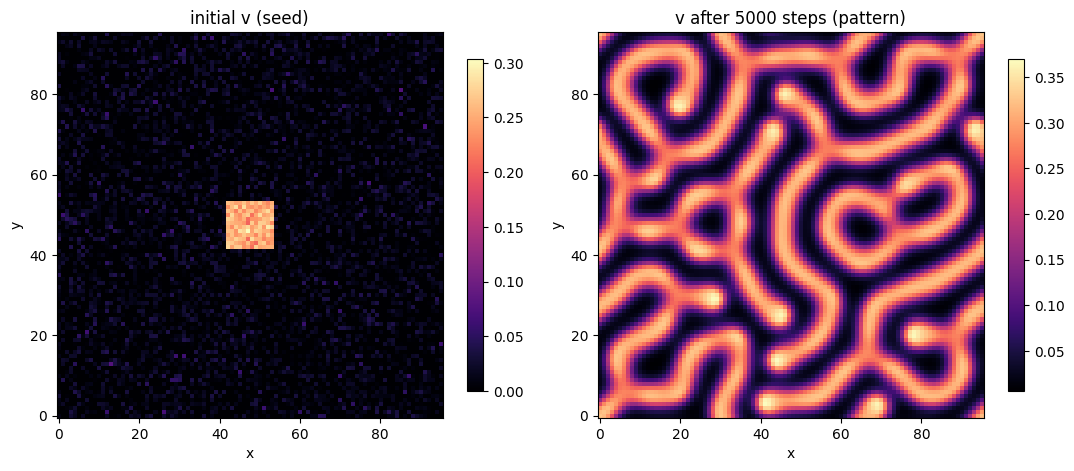

pattern formed: v spatial std = 0.1073 (0 would be uniform)


In [5]:
# Gray-Scott reaction-diffusion: a tiny seed self-organizes into a Turing pattern.
u0, v0 = advanced.gray_scott_seed(n=96, seed=0)
u, v = advanced.solve_gray_scott(u0, v0, Du=0.16, Dv=0.08, feed=0.035, kill=0.06,
                                 dx=1.0, dt=1.0, steps=5000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
plotting.heatmap_2d(v0, ax=a1, cmap="magma", title="initial v (seed)")
plotting.heatmap_2d(v, ax=a2, cmap="magma", title="v after 5000 steps (pattern)")
fig.tight_layout()
plt.show()
print("pattern formed: v spatial std =", round(float(v.std()), 4), "(0 would be uniform)")

## 4. 2 次元の波動 — 膜の振動

弦(1D)を膜(2D)に拡げます。$u_{tt}=c^2(u_{xx}+u_{yy})$。中央を弾くと、**円形の波** が広がり、
縁で反射して干渉します。2 次元の CFL 条件は $c\,\Delta t/\Delta x \le 1/\sqrt{2}$ と少し厳しくなります。

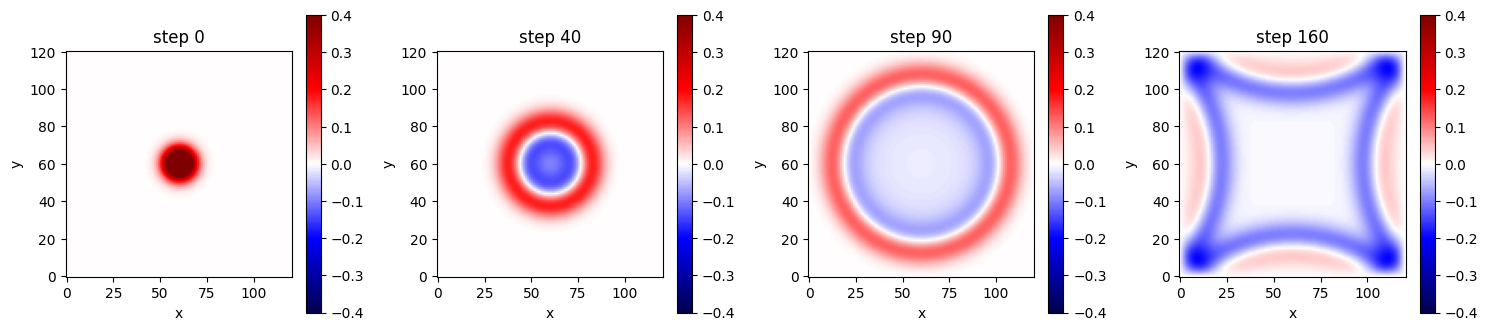

In [6]:
# 2-D wave: a central pluck spreads as a circular wave and reflects off the edges.
n, c = 121, 1.0
xs = np.linspace(0, 1, n)
dx = xs[1] - xs[0]
X, Y = np.meshgrid(xs, xs)
u0 = np.exp(-(((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.004))
dt = 0.5 * dx / c
U = advanced.solve_wave_2d(u0, np.zeros_like(u0), c, dx, dt, 160)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, kk in zip(axes, (0, 40, 90, 160)):
    plotting.heatmap_2d(U[kk], ax=ax, cmap="seismic", title=f"step {kk}")
    ax.images[0].set_clim(-0.4, 0.4)
fig.tight_layout()
plt.show()

## Exercises

1. スペクトル法で $\sin(kx)$ の導関数 $k\cos(kx)$ を FFT(波数 $ik$ 倍)で求め、差分との誤差を比べよ。
2. KdV で背の高さ(`amp`)を変え、速度が $\text{amp}^2$ に比例することを数値で確かめよ。
3. Gray-Scott の `feed`/`kill` を変え、斑点・縞・迷路など異なるパターンが出ることを観察せよ。
4. 2 次元波動で初期速度(たたく)を与え、はじく場合との違いを比べよ。

## Advanced Notes

- **整数因子 (integrating factor)**: KdV の硬い線形項 $u_{xxx}$ を Fourier 空間で厳密に積分し、非線形項だけ RK4 で進める(本実装)。これで時間刻みを大きく取れる。
- **逆散乱変換**: KdV は完全可積分で、ソリトンの個数・速度は保存量。衝突で位相だけずれる。
- **Turing 不安定性**: 拡散係数比 $D_v/D_u$ が小さい(活性化因子が遅く拡散)とき、一様解が空間モードに不安定化する。
- **スペクトル法の限界**: 非周期・不連続・複雑形状では Gibbs 振動や境界処理が問題。実務は有限要素 (FEM) やスペクトル要素法。